In [ ]:
#!pip -q install pandas==3.0.1
#!pip -q install numpy==2.4.2
#!pip -q install matplotlib==3.10.8
#!pip -q install scipy==1.17.1
#!pip -q install scikit-learn==1.8.0
#!pip -q install xgboost==3.2.0
#!pip -q install category-encoders==2.9.0
#!pip -q install joblib==1.5.3
#!pip -q install seaborn==0.13.2
#!python --version

Python 3.12.3


In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
#from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from category_encoders import TargetEncoder

import time
import seaborn as sns

from cycler import cycler
theme = {
    "figure_bg": "#02030D",
    "axes_bg":   "#26262F",
    "text":      "#E7D8DE",
    "text_1":    "#02030D",
    "muted":     "#B7AEB8",
    "grid":      "#4A4C59",
    "spine":     "#5A5D6B",
    "purple":    "#B07CF8",
    "blue":      "#8ED6F8",
    "lavender":  "#9EA8FF",
}

plt.rcParams.update({
    "figure.facecolor": theme["figure_bg"],
    "axes.facecolor": theme["axes_bg"],
    "axes.edgecolor": theme["spine"],
    "axes.labelcolor": theme["text"],
    "axes.titlecolor": theme["lavender"],
    "xtick.color": theme["muted"],
    "ytick.color": theme["muted"],
    "grid.color": theme["grid"],
    "text.color": theme["text"],
    "legend.facecolor": theme["axes_bg"],
    "legend.edgecolor": theme["spine"],
    "legend.labelcolor": theme["text"],
    "savefig.facecolor": theme["figure_bg"],
    "savefig.edgecolor": theme["figure_bg"],
    "axes.prop_cycle": cycler(color=[
        theme["purple"],
        theme["blue"],
        theme["lavender"],
        "#C9A7FF",
        "#A5E3FF"
    ])
})

timestamp = time.strftime("%m_%d_%H_%M_%S", time.localtime())
#joblib.dump(result, f'{name}_{timestamp}.pkl')
folder = f"./content_{timestamp}"
print(folder)
!mkdir -p {folder}

ready_to_model = True  # "yes" or "no"
use_location_cluster = True

location_scope = "region"  # "NONE", "CONUS", "STATE", "REGION"


./content_04_08_16_40_17


# Phase 2

In [350]:
df = pd.read_csv("housing_resized.csv")
start_size = len(df)
print(f"Initial dataset size: {start_size}")

Initial dataset size: 384977


In [351]:
def summary_table(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = []

    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": ((df.isnull().sum() / len(df)) * 100).values
    })

    if categorical_cols is not None:
        summary["Num Categories"] = [
            df[col].nunique(dropna=False) if col in categorical_cols else None
            for col in df.columns
        ]


    return summary

In [352]:
total_duplicates = df.duplicated().sum()
id_duplicates = df.duplicated(subset=["id"]).sum()
print(f"There are {total_duplicates} duplicate rows in the dataset.")
print(f"There are {id_duplicates} duplicate values based on the 'id' column.")

count = (df["state"].astype(str).str.len() > 2).sum()
print(f"There are {count} rows where 'state' is more than 2 characters long.")

def summary_table_2(df):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": ((df.isnull().sum() / len(df)) * 100).values
    })
    return summary
summary_table_1 = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": ((df.isnull().sum() / start_size) * 100).values
})

categorical_cols = ["region","type","cats_allowed", "dogs_allowed", 
                    "smoking_allowed", "wheelchair_access", "electric_vehicle_charge", 
                    "comes_furnished", "laundry_options", "parking_options", "state", ]
display(summary_table(df, categorical_cols))
#display(summary_table(df),None)

display(df.describe())

There are 0 duplicate rows in the dataset.
There are 0 duplicate values based on the 'id' column.
There are 0 rows where 'state' is more than 2 characters long.


,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,id,int64,384977,0,0.000000,NaN
1,region,str,384977,0,0.000000,404.0
2,price,int64,384977,0,0.000000,NaN
3,type,str,384977,0,0.000000,12.0
4,sqfeet,int64,384977,0,0.000000,NaN
5,beds,int64,384977,0,0.000000,NaN
6,baths,float64,384977,0,0.000000,NaN
7,cats_allowed,int64,384977,0,0.000000,2.0
8,dogs_allowed,int64,384977,0,0.000000,2.0
9,smoking_allowed,int64,384977,0,0.000000,2.0


,id,price,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,lat,long
count,3.849770e+05,3.849770e+05,3.849770e+05,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,384977.000000,383059.000000,383059.000000
mean,7.040982e+09,8.825722e+03,1.059900e+03,1.905345,1.480718,0.726890,0.707918,0.731771,0.082111,0.012871,0.048128,37.233487,-92.700631
std,8.800376e+06,4.462200e+06,1.915076e+04,3.494572,0.618061,0.445557,0.454721,0.443038,0.274535,0.112718,0.214036,5.546171,16.531980
min,7.003808e+09,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-43.533300,-163.894000
25%,7.035979e+09,8.050000e+02,7.500000e+02,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.454700,-100.775000
50%,7.043320e+09,1.036000e+03,9.490000e+02,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,37.647800,-87.745100
75%,7.048426e+09,1.395000e+03,1.150000e+03,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,41.138300,-81.179600
max,7.051292e+09,2.768307e+09,8.388607e+06,1100.000000,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,102.036000,172.633000


In [353]:
def map_show_1(df):
    plt.figure(figsize=(10, 6), facecolor="#FFF2CC")
    plt.scatter(df["long"], df["lat"], alpha=0.3, s=10)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Housing Listing Locations (Longitude vs Latitude)")
    plt.tight_layout()
    #plt.savefig(f"{folder}/{title}.png") 
    plt.show()




def map_show(df, title = "Housing Listing Locations"):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.scatter(
        df["long"], df["lat"],
        color=theme["blue"],
        alpha=0.35,
        s=10
    )

    ax.set_title(label = title, pad=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(True, alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()

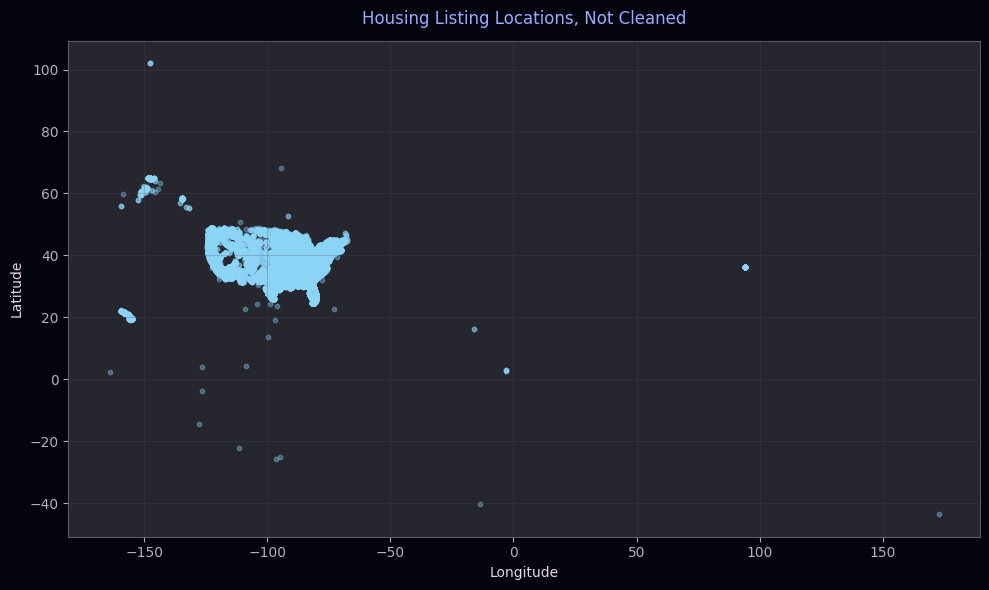

In [354]:
map_show(df, "Housing Listing Locations, Not Cleaned")

# Phase 3

In [355]:
#Task 3.1 : Selecting Data…
df_selected = df.drop(columns=['id', 'url', 'image_url', 'description'], errors='ignore')
#df_selected



In [356]:
def check_outliers_multiple(df, cutoffs):
    results = {}
    outliers_sum = 0
    for column, (low_cutoff, high_cutoff) in cutoffs.items():
        outliers = df[(df[column] < low_cutoff) | (df[column] > high_cutoff)]
        results[column] = len(outliers)
        outliers_sum += len(outliers)

    results["total"] = outliers_sum
    return results

cutoffs = {
    "price": (1, max(df["price"])),
    "sqfeet": (70, max(df["sqfeet"]))
}

outlier_counts = check_outliers_multiple(df_selected, cutoffs)
print(outlier_counts)

print(f"These properties represent {(outlier_counts['total'] / start_size) * 100:.2f}% of the dataset.")


{'price': 1307, 'sqfeet': 929, 'total': 2236}
These properties represent 0.58% of the dataset.


Rows before: 384977, after: 382787, removed: 2190 (0.57%)


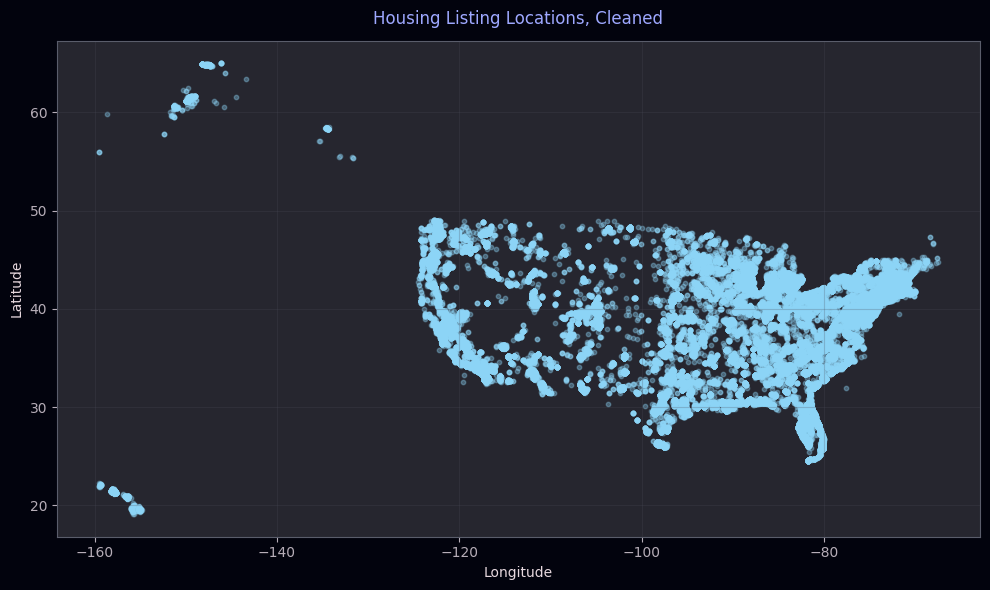

REGION Applied per-region IQR filtering on price.
Rows before: 382787, after: 362781, removed: 20006 (5.23%)


,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,region,str,362781,0,0.000000,None
1,price,int64,362781,0,0.000000,None
2,type,str,362781,0,0.000000,None
3,sqfeet,int64,362781,0,0.000000,None
4,beds,int64,362781,0,0.000000,None
5,baths,float64,362781,0,0.000000,None
6,cats_allowed,int64,362781,0,0.000000,None
7,dogs_allowed,int64,362781,0,0.000000,None
8,smoking_allowed,int64,362781,0,0.000000,None
9,wheelchair_access,int64,362781,0,0.000000,None


In [357]:
# Task 3.2 : Cleaning Data…

clean_long_lat = True

if clean_long_lat == True:
    before = start_size

    # CONUS
    conus_mask = (
        df_selected["lat"].between(25, 49.5) &
        df_selected["long"].between(-125, -66.5)
    )

    # Alaska + Hawaii box
    ak_hi_mask = (
        df_selected["lat"].between(18, 66) &
        df_selected["long"].between(-160.5, -130)
    )

    # South Florida override box
    south_fl_mask = (
        df_selected["lat"].between(23, 26) &
        df_selected["long"].between(-83, -79)
    )

    # Keep anything inside at least one valid box
    keep_mask = conus_mask | ak_hi_mask | south_fl_mask

    df_cleaned = df_selected[keep_mask].copy()
    after = len(df_cleaned)

    print(
        f"Rows before: {before}, after: {after}, removed: {before - after} "
        f"({(before - after) / before:.2%})"
    )

map_show(df_cleaned, "Housing Listing Locations, Cleaned")



# ------------------------------
# 2) Target / features
# ------------------------------
TARGET = "price"

# -----------------------------------
# IQR option
# Valid options: "NONE", "CONUS", "STATE", "REGION"
# -----------------------------------


I = 1.5  # IQR multiplier
z = 1.72 # z-score
k= I

def clean_outliers(
    df,
    TARGET='price',
    scope="CONUS",
    k=1.5#,
    #z_thresh=3
):
        scope = scope.lower()
        if scope == "conus":
            q1 = df[TARGET].quantile(0.25)
            q3 = df[TARGET].quantile(0.75)
        else:
            q1 = df.groupby(scope)[TARGET].transform(lambda s: s.quantile(0.25))
            q3 = df.groupby(scope)[TARGET].transform(lambda s: s.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr

        before = len(df)
        mask = (df[TARGET] >= lower) & (df[TARGET] <= upper)
        df = df[mask].copy()
        after = len(df)

        print(f"{scope.upper()} Applied per-region IQR filtering on price.")
        print(f"Rows before: {before}, after: {after}, removed: {before - after} ({(before - after) / before:.2%})")

        return df

#df_cleaned_conus = clean_outliers(df_cleaned, TARGET=TARGET, scope="CONUS", k=k)
#df_cleaned_state = clean_outliers(df_cleaned, TARGET=TARGET, scope="state", k=k)
#df_cleaned_region = clean_outliers(df_cleaned, TARGET=TARGET, scope="region", k=k)

df_cleaned_region = clean_outliers(df_cleaned, TARGET=TARGET, scope=location_scope, k=k)

display(summary_table(df_cleaned_region))

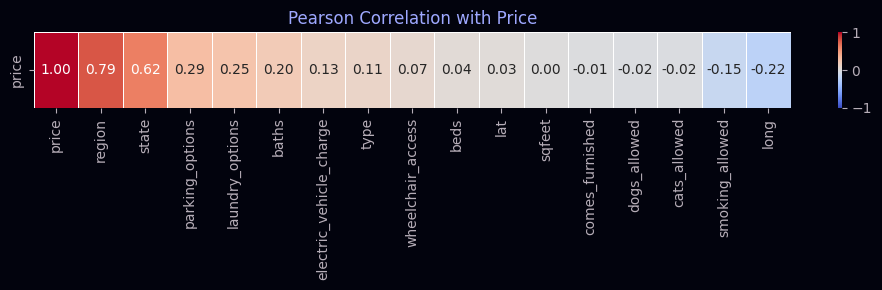

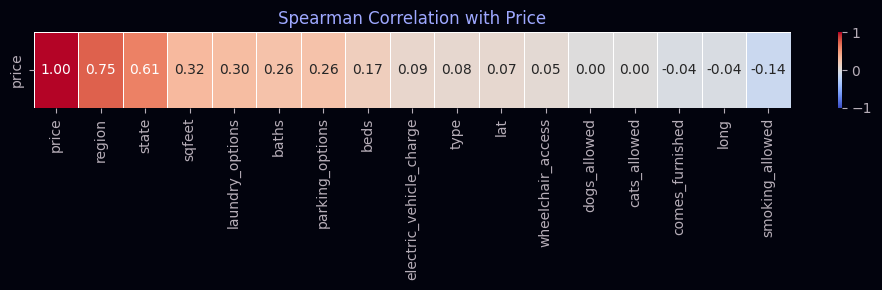

In [358]:
# Correlation heatmap with price only (after encoding)

cols = ["price", "sqfeet", "beds", "baths", "cats_allowed", "dogs_allowed",
        "smoking_allowed", "wheelchair_access", "electric_vehicle_charge",
        "comes_furnished", "lat", "long",
        "type", "laundry_options", "parking_options", "state", "region"]

df_heat = df_cleaned_region[cols].copy()

categorical_cols = ["type", "laundry_options", "parking_options", "state", "region"]
numeric_cols = [c for c in df_heat.columns if c not in categorical_cols + ["price"]]

X = df_heat.drop(columns=["price"]).copy()
y = df_heat["price"].copy()

# fill missing values
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0]).astype(str)

# target encode categorical columns
encoder = TargetEncoder(cols=categorical_cols)
X_enc = encoder.fit_transform(X, y)

# combine target + encoded features
df_enc = pd.concat([y, X_enc], axis=1)

# correlation with price only
corr_price_pearson = df_enc.corr(numeric_only=True)[["price"]].sort_values(by="price", ascending=False).T
corr_price_spearman = df_enc.corr(method="spearman", numeric_only=True)[["price"]].sort_values(by="price", ascending=False).T

def plot_correlation_heatmap(corr_matrix, title):
    plt.figure(figsize=(10, 3))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, center=0)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()

plot_correlation_heatmap(corr_price_pearson, "Pearson Correlation with Price")
plot_correlation_heatmap(corr_price_spearman, "Spearman Correlation with Price")



In [359]:
display(summary_table(df_cleaned_region))

,Column,Data Type,Non-Null Count,Missing Values,Missing %,Num Categories
0,region,str,362781,0,0.000000,None
1,price,int64,362781,0,0.000000,None
2,type,str,362781,0,0.000000,None
3,sqfeet,int64,362781,0,0.000000,None
4,beds,int64,362781,0,0.000000,None
5,baths,float64,362781,0,0.000000,None
6,cats_allowed,int64,362781,0,0.000000,None
7,dogs_allowed,int64,362781,0,0.000000,None
8,smoking_allowed,int64,362781,0,0.000000,None
9,wheelchair_access,int64,362781,0,0.000000,None


In [360]:
#Task 3.3 : Constructing Data…
X = df_cleaned_region.drop(columns=[TARGET]).copy()
y = df_cleaned_region[TARGET].copy()

# ------------------------------
# 3) Train / test split
# ------------------------------
if use_location_cluster == True:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    print("Shapes => X:", X.shape, "X_train:", X_train.shape, "X_test:", X_test.shape)
    
    N_CLUSTERS = int(50*2.5)
    coord_cols = ["lat", "long"]
    
    coord_imputer = SimpleImputer(strategy="median")
    
    train_coords = pd.DataFrame(
        coord_imputer.fit_transform(X_train[coord_cols]),
        columns=coord_cols,
        index=X_train.index
    )
    
    test_coords = pd.DataFrame(
        coord_imputer.transform(X_test[coord_cols]),
        columns=coord_cols,
        index=X_test.index
    )
    
    #print(train_coords)
    #print(test_coords)
    
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    X_train["location_cluster"] = kmeans.fit_predict(train_coords).astype(str)
    X_test["location_cluster"] = kmeans.predict(test_coords).astype(str)

Shapes => X: (362781, 16) X_train: (290224, 16) X_test: (72557, 16)


In [361]:
#Task 3.5 : Formatting Data…

# ------------------------------
# 5) Column groups
# ------------------------------
categorical_cols = [
    "type",
    "laundry_options",
    "parking_options",
    "state",
    #"location_cluster",
    "region"
]

if use_location_cluster == True:
    categorical_cols.append("location_cluster")

X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

special_missing_cols = ["laundry_options", "parking_options"]

for col in categorical_cols:
    if col in special_missing_cols:
        X_train_cat[col] = X_train_cat[col].fillna("Missing").astype(str)
        X_test_cat[col] = X_test_cat[col].fillna("Missing").astype(str)
    else:
        most_freq = X_train_cat[col].mode()[0]
        X_train_cat[col] = X_train_cat[col].fillna(most_freq).astype(str)
        X_test_cat[col] = X_test_cat[col].fillna(most_freq).astype(str)

numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# ------------------------------
# 6) Minimal preprocessing
#    - numeric: median impute
#    - categorical: most_frequent impute
#    - then target encode categoricals
# ------------------------------
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

# categorical preprocessing
special_missing_cols = ["laundry_options", "parking_options"]
other_categorical_cols = [col for col in categorical_cols if col not in special_missing_cols]

# start from raw categorical columns
X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()

# keep missing as its own category for selected columns
for col in special_missing_cols:
    if col in X_train_cat.columns:
        X_train_cat[col] = X_train_cat[col].fillna("Missing")
        X_test_cat[col] = X_test_cat[col].fillna("Missing")

# most frequent imputation for the remaining categorical columns
if len(other_categorical_cols) > 0:
    X_train_cat[other_categorical_cols] = cat_imputer.fit_transform(X_train_cat[other_categorical_cols])
    X_test_cat[other_categorical_cols] = cat_imputer.transform(X_test_cat[other_categorical_cols])

# convert all categorical values to string
X_train_cat = X_train_cat.astype(str)
X_test_cat = X_test_cat.astype(str)


encoder = TargetEncoder(
    cols=categorical_cols,
    handle_missing="value",
    handle_unknown="value",
    smoothing=10
)

X_train_cat_enc = encoder.fit_transform(X_train_cat, y_train)
X_test_cat_enc = encoder.transform(X_test_cat)

# Final matrices
X_train_final = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_enc], axis=1)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)
display(X_train_final.head())

Numeric columns: ['sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'lat', 'long']
Categorical columns: ['type', 'laundry_options', 'parking_options', 'state', 'region', 'location_cluster']
Final train shape: (290224, 17)
Final test shape: (72557, 17)


,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,lat,long,type,laundry_options,parking_options,state,region,location_cluster
223309,1050.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,41.1377,-81.5539,1128.453147,1091.987916,1098.384394,839.860097,832.474338,857.437950
315486,850.0,2.0,1.5,1.0,1.0,0.0,0.0,0.0,0.0,33.9675,-98.6868,1128.453147,971.608600,1098.384394,975.039316,757.877746,723.797425
253848,1002.0,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,39.9695,-75.1396,1128.453147,1356.816412,1136.588796,1182.697915,1527.410901,1327.604478
126007,524.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,29.6252,-90.7623,1128.453147,1356.816412,1098.384394,901.530986,845.793501,835.966470
94989,755.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,38.6185,-90.2564,1128.453147,1024.319409,1136.588796,933.145648,892.704142,893.249602


# Task 4

In [362]:
#Task 4.1

def time_callable(func, name,*args, **kwargs):
    start_time = time.perf_counter()
    result = func(*args, **kwargs)
    duration = time.perf_counter() - start_time

    print(f"\ntraining took: {duration:.2f} seconds, {duration / 60:.0f}min:{duration%60:.1f}sec")
    #timestamp = time.strftime("%m_%d_%H_%M_%S", time.localtime())
    joblib.dump(result, f'{folder}/{name}_{timestamp}.pkl')
    return result, duration

# ------------------------------
# Models
# ------------------------------
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# ------------------------------
# XGBoost model
# ------------------------------
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [363]:
#Task 4.3

if ready_to_model == True:
    print("")
    # ------------------------------
    # 8) Train
    # ------------------------------
    print("Training Random Forest...")
    rf_model, _ = time_callable(rf_model.fit, 'rf_model', X_train_final, y_train)
    #rf_model.fit(X_train_final, y_train)

    print("Training Gradient Boosting...")
    gb_model, _ = time_callable(gb_model.fit, 'gb_model', X_train_final, y_train)
    #gb_model.fit(X_train_final, y_train)

    print("Training X Gradient Boosting...")
    xgb_model, _ = time_callable(xgb_model.fit, 'xgb_model', X_train_final, y_train)

    # ------------------------------
    # 9) Predict
    # ------------------------------
    rf_pred = rf_model.predict(X_test_final)
    gb_pred = gb_model.predict(X_test_final)
    xgb_pred = xgb_model.predict(X_test_final)
    


Training Random Forest...

training took: 330.18 seconds, 6min:30.2sec
Training Gradient Boosting...

training took: 250.44 seconds, 4min:10.4sec
Training X Gradient Boosting...

training took: 8.65 seconds, 0min:8.6sec


,Model,MAE,MSE,RMSE,R2,ASE,SSE,Observed Avg
0,Random Forest,62.695,18989.253,137.801,0.922,18989.253,1.377803e+09,1140.944
1,Gradient Boosting,150.683,48890.339,221.112,0.799,48890.339,3.547336e+09,1140.944
2,XGBoost,124.333,34454.191,185.618,0.858,34454.191,2.499893e+09,1140.944


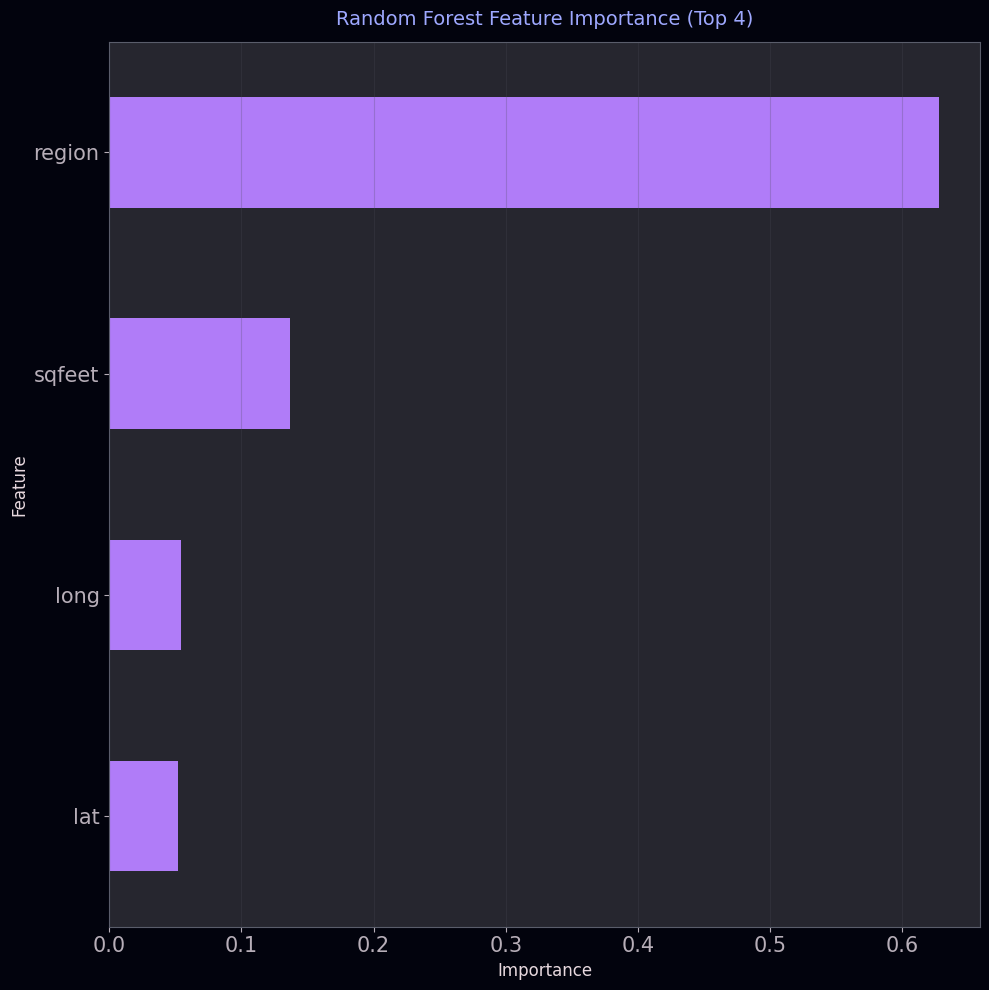

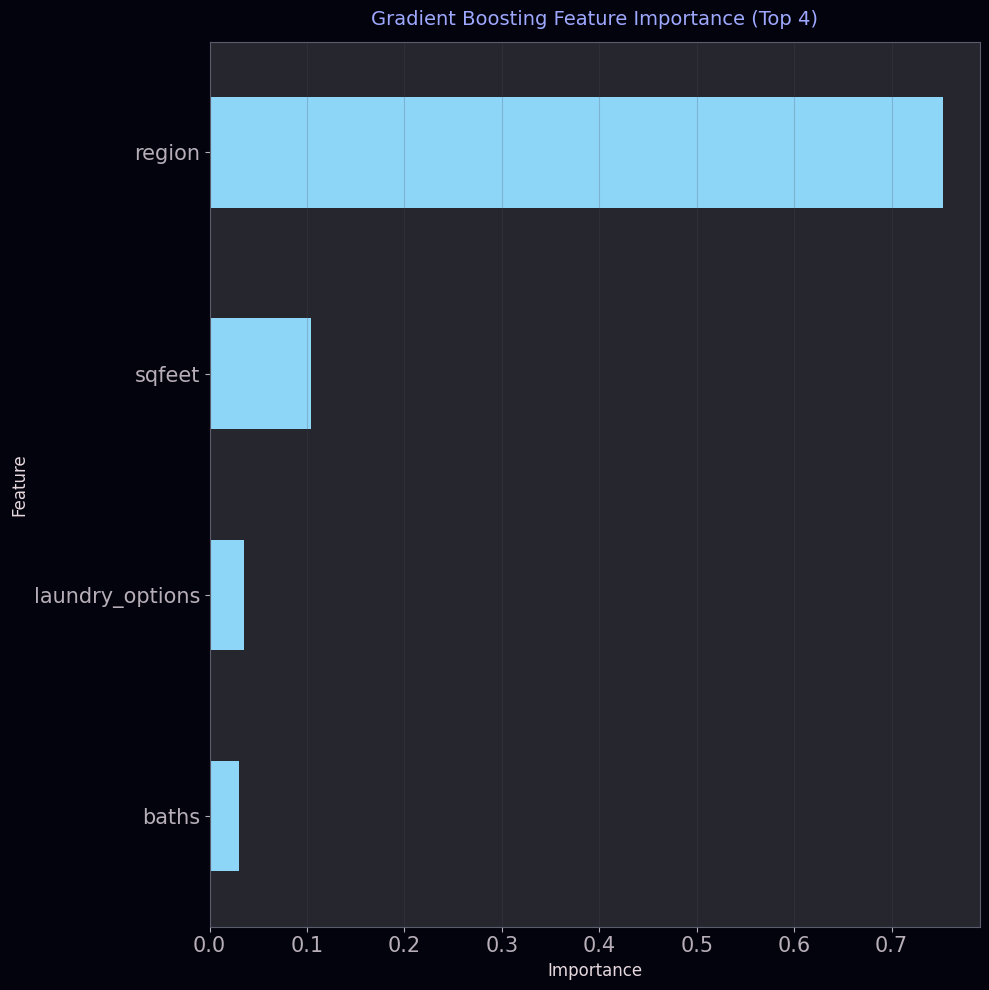

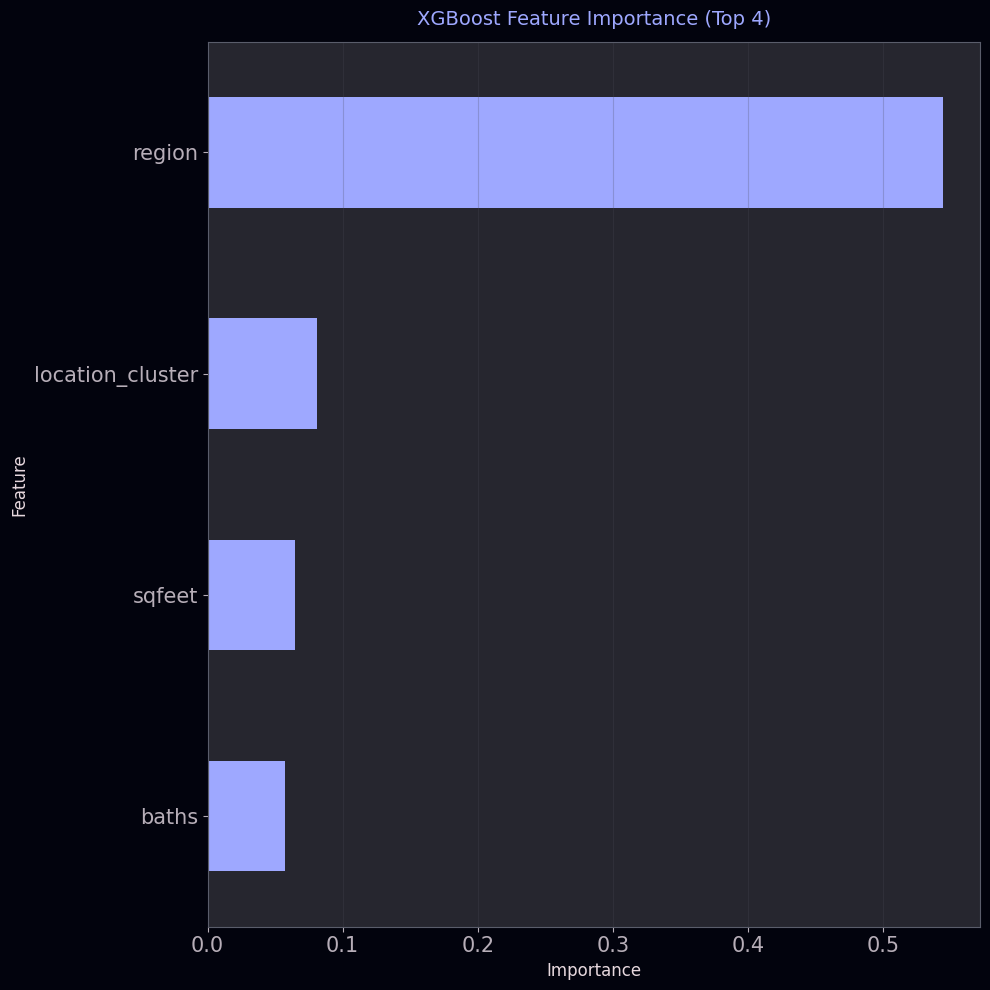

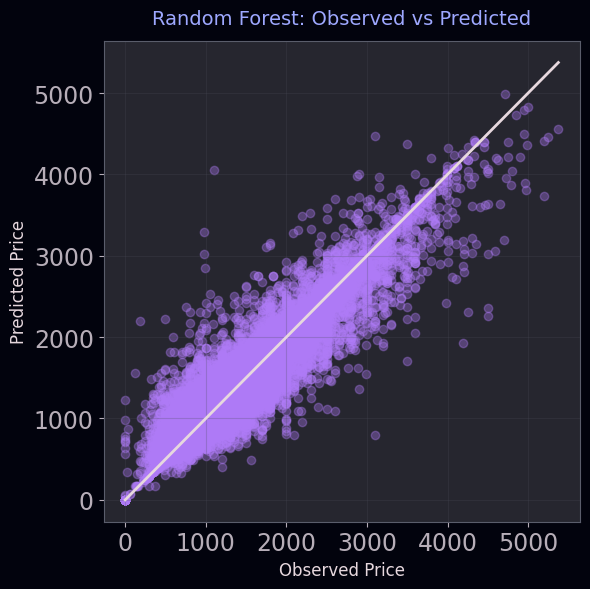

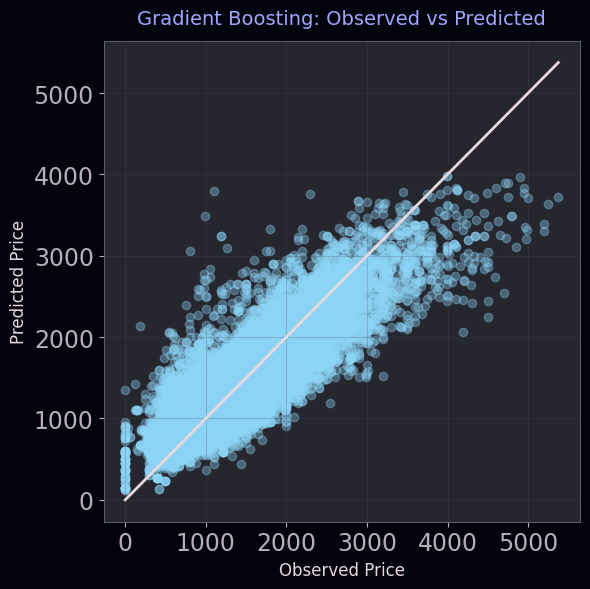

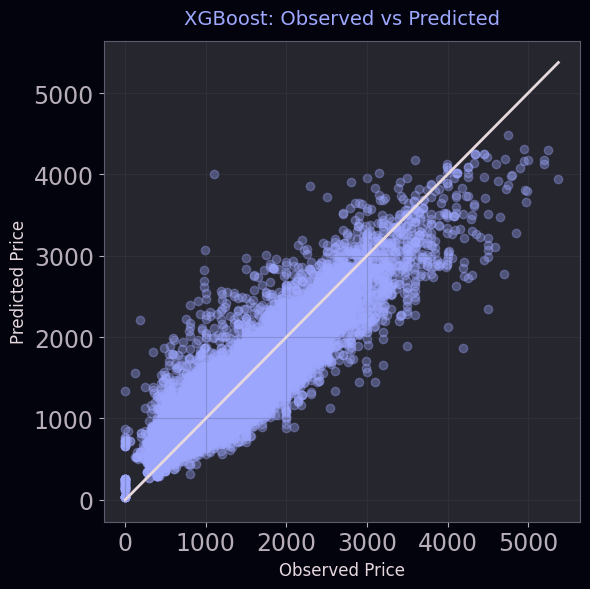

In [364]:
# ------------------------------
# 10) Metrics
# ------------------------------
def get_model_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    ase = mse
    sse = np.sum((y_true - y_pred) ** 2)
    observed_avg = np.mean(y_true)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "ASE": ase,
        "SSE": sse,
        "Observed Avg": observed_avg
    }

# Build results DataFrame
results_df = pd.DataFrame([
    get_model_metrics("Random Forest", y_test, rf_pred),
    get_model_metrics("Gradient Boosting", y_test, gb_pred),
    get_model_metrics("XGBoost", y_test, xgb_pred)
])

display(results_df.round(3))


#results_df_save = results_df.copy()

#results_df_save = results_df_save.round(3)

results_df_save = results_df.round({
    "MAE": 2,
    "MSE": 1,
    "RMSE": 2,
    "R2": 3,
    "ASE": 1,
    "SSE": 1,
    "Observed Avg": 2
}).copy()


results_df_save = results_df_save.rename(columns={
    "Observed Avg": "ObservedAvg"
})

results_df_save.to_csv(f"{folder}/model_performance_metrics.csv", index=False)

# ------------------------------
# 11) Feature importance plots
#     No one-hot split problem here:
#     each original categorical column stays one encoded column
# ------------------------------
feature_names = X_train_final.columns.tolist()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)


top_n = 4#8

def styled_barh(series, title, bar_color):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    series.head(top_n).sort_values().plot(
        kind="barh",
        ax=ax,
        color=bar_color,
        width = 0.5
    )

    #title = title.replace("_", "\n").replace(" ", "\n")
    ax.set_title(title, color=theme["lavender"], pad=12, fontsize=14)
    ax.set_xlabel("Importance", color=theme["text"], fontsize=12)
    ax.set_ylabel("Feature", color=theme["text"], fontsize=12)
    ax.tick_params(colors=theme["muted"], labelsize=15)
    ax.grid(axis="x", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()


def styled_barh_1(series, title, bar_color):
    s = series.head(top_n).sort_values()

    bar_height = 0.2
    spacing = 0.05
    step = bar_height + spacing

    y = np.arange(len(s)) * step

    fig, ax = plt.subplots(figsize=(10, 10), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.barh(
        y,
        s.values,
        height=bar_height,
        color=bar_color
    )

    ax.set_yticks(y)
    ax.set_yticklabels(s.index)

    ax.set_title(title, color=theme["lavender"], pad=12)
    ax.set_xlabel("Importance", color=theme["text"])
    ax.set_ylabel("Feature", color=theme["text"])
    ax.tick_params(colors=theme["muted"], labelsize=15)
    ax.grid(axis="x", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.show()

styled_barh(rf_importance, f"Random Forest Feature Importance (Top {top_n})", theme["purple"])
styled_barh(gb_importance, f"Gradient Boosting Feature Importance (Top {top_n})", theme["blue"])
styled_barh(xgb_importance, f"XGBoost Feature Importance (Top {top_n})", theme["lavender"])


#display(rf_importance.to_frame("RF_Importance").head(20))
#display(gb_importance.to_frame("GB_Importance").head(20))
#display(xgb_importance.to_frame("XGB_Importance").head(20))

# ------------------------------
# 12) Optional: observed vs predicted
# ------------------------------
def styled_observed_vs_pred(y_true, y_pred, title, point_color):
    fig, ax = plt.subplots(figsize=(6, 6), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.scatter(y_true, y_pred, alpha=0.35, color=point_color)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color=theme["text"],
        linewidth=2
    )

    ax.set_xlabel("Observed Price", color=theme["text"], fontsize=12)
    ax.set_ylabel("Predicted Price", color=theme["text"], fontsize=12)
    ax.set_title(title, color=theme["lavender"], pad=12, fontsize=14)
    ax.tick_params(colors=theme["muted"], labelsize=17)
    ax.grid(True, color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}.png") 
    plt.show()


styled_observed_vs_pred(y_test, rf_pred, "Random Forest: Observed vs Predicted", theme["purple"])
styled_observed_vs_pred(y_test, gb_pred, "Gradient Boosting: Observed vs Predicted", theme["blue"])
styled_observed_vs_pred(y_test, xgb_pred, "XGBoost: Observed vs Predicted", theme["lavender"])

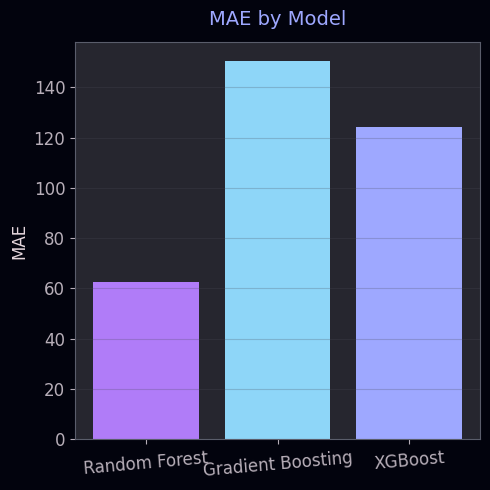

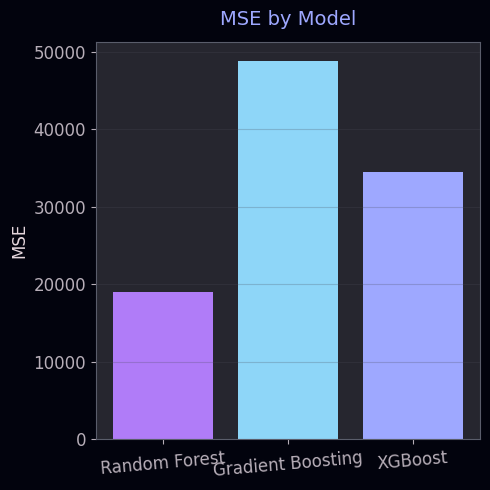

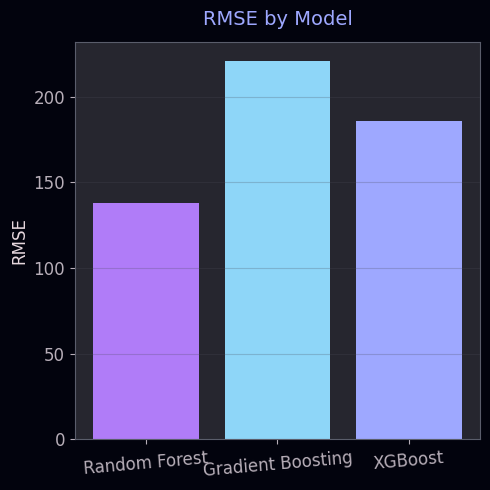

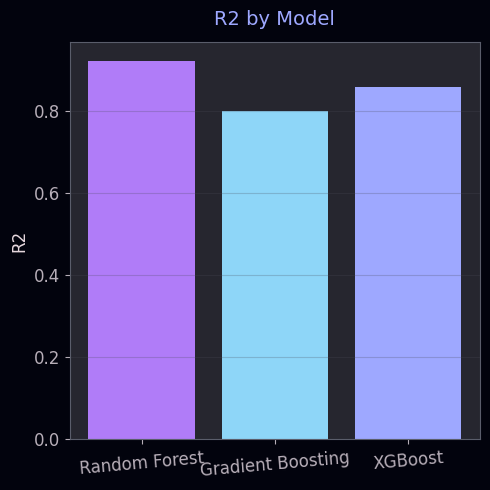

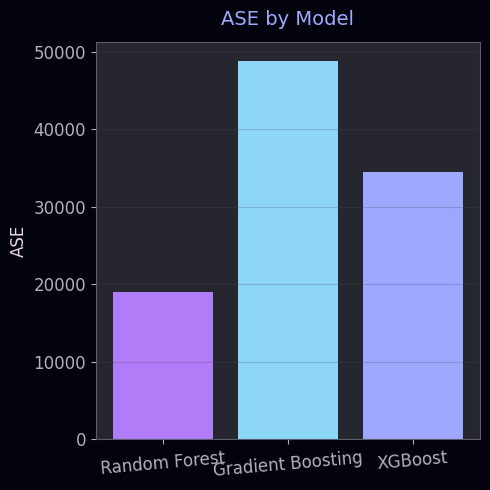

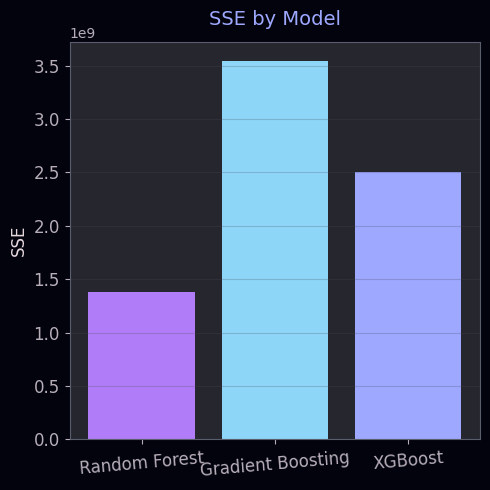

In [365]:




metrics_to_plot = ["MAE", "MSE", "RMSE", "R2", "ASE", "SSE"]

bar_colors = [theme["purple"], theme["blue"], theme["lavender"]]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(5, 5), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    colors = [bar_colors[i % len(bar_colors)] for i in range(len(results_df))]

    ax.bar(
        results_df["Model"],
        results_df[metric],
        color=colors
    )

    ax.set_title(f"{metric} by Model", color=theme["lavender"], pad=12, fontsize=14)
    #ax.set_xlabel("Model", color=theme["text"], fontsize=12)
    ax.set_ylabel(metric, color=theme["text"], fontsize=12)
    ax.tick_params(axis="x", colors=theme["muted"], rotation=5, labelsize=12)
    ax.tick_params(axis="y", colors=theme["muted"], labelsize=12)
    ax.grid(axis="y", color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{metric} by Model.png") 
    plt.show()

/home/gordon/Documents/MonU/MonU/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


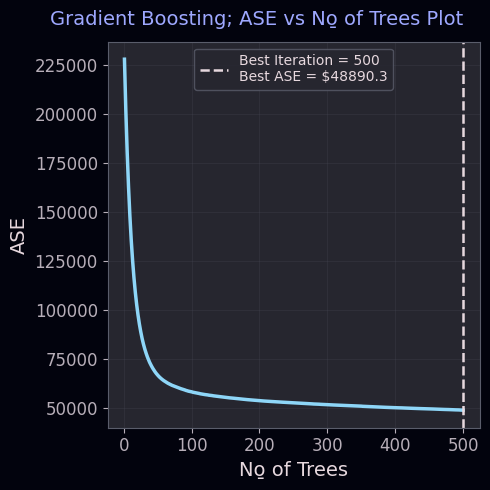

Gradient Boosting best iteration: 500
Gradient Boosting best ASE: 48,890.3392


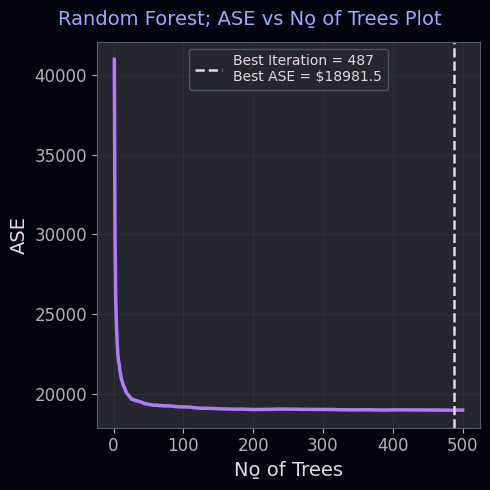

Random Forest best number of trees on test curve: 487
Random Forest best ASE: 18,981.4838


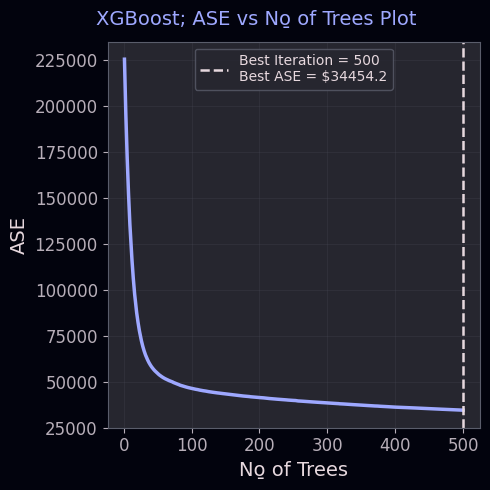

Best number of trees: 500
Best ASE: 34,454.1914


In [366]:
def styled_iteration_plot(x, y, title, best, line_color):
    fig, ax = plt.subplots(figsize=(5, 5), facecolor=theme["figure_bg"])
    ax.set_facecolor(theme["axes_bg"])

    ax.plot(x, y, color=line_color, linewidth=2.5)
    ax.axvline(
        best[0],
        color=theme["text"],
        linestyle="--",
        linewidth=1.8,
        label=f"Best Iteration = {best[0]} \nBest ASE = ${best[1].round(1)}"

    )

    ax.set_xlabel("No̱ of Trees", color=theme["text"], fontsize=14)
    ax.set_ylabel("ASE", color=theme["text"], fontsize=14)
    ax.set_title(title, color=theme["lavender"], pad=12 , fontsize=14).set_x(0.4)
    ax.tick_params(axis="x", colors=theme["muted"], labelsize=12)
    ax.tick_params(axis="y", colors=theme["muted"], labelsize=12)
    ax.grid(True, color=theme["grid"], alpha=0.25)

    for spine in ax.spines.values():
        spine.set_color(theme["spine"])

    legend = ax.legend(facecolor=theme["axes_bg"], edgecolor=theme["spine"])
    for text in legend.get_texts():
        text.set_color(theme["text"])

    plt.tight_layout()
    plt.savefig(f"{folder}/{title}_2.png")
    plt.show()


# ------------------------------
# 14) Iteration / Error plots
# ------------------------------
X_test_np = X_test_final.to_numpy()
# ---------- 14A. Gradient Boosting Iteration Plot ----------
gb_ase = []

for y_pred_stage in gb_model.staged_predict(X_test_np):
    ase = mean_squared_error(y_test, y_pred_stage)
    gb_ase.append(ase)

gb_best_iter = np.argmin(gb_ase) + 1
gb_best_ase = np.min(gb_ase)

styled_iteration_plot(
    x=range(1, len(gb_ase) + 1),
    y=gb_ase,
    title="Gradient Boosting; ASE vs No̱ of Trees Plot",
    best=[gb_best_iter, gb_best_ase],
    line_color=theme["blue"]
)
#"Gradient Boosting Iteration Plot (ASE vs № No̱ Nº, No̱, or no of Trees)"
print(f"Gradient Boosting best iteration: {gb_best_iter}")
print(f"Gradient Boosting best ASE: {gb_best_ase:,.4f}")


# ---------- 14B. Random Forest Error Plot ----------
rf_ase = []
rf_running_pred = np.zeros(len(X_test_np), dtype=float)

for i, tree in enumerate(rf_model.estimators_, start=1):
    tree_pred = tree.predict(X_test_np)
    rf_running_pred += tree_pred

    rf_avg_pred = rf_running_pred / i
    ase = mean_squared_error(y_test, rf_avg_pred)
    rf_ase.append(ase)

rf_best_trees = np.argmin(rf_ase) + 1
rf_best_ase = np.min(rf_ase)

styled_iteration_plot(
    x=range(1, len(rf_ase) + 1),
    y=rf_ase,
    title="Random Forest; ASE vs No̱ of Trees Plot",
    best=[rf_best_trees, rf_best_ase],
    line_color=theme["purple"]
)

print(f"Random Forest best number of trees on test curve: {rf_best_trees}")
print(f"Random Forest best ASE: {rf_best_ase:,.4f}")


# ---------- 14C. XGBoost Iteration Plot ----------
xgb_ase = []

if hasattr(xgb_model, "best_iteration") and xgb_model.best_iteration is not None:
    max_trees = xgb_model.best_iteration + 1
else:
    max_trees = xgb_model.n_estimators

for i in range(1, max_trees + 1):
    y_pred_i = xgb_model.predict(X_test_np, iteration_range=(0, i))
    ase_i = mean_squared_error(y_test, y_pred_i)
    xgb_ase.append(ase_i)

best_trees = np.argmin(xgb_ase) + 1
best_ase = np.min(xgb_ase)

styled_iteration_plot(
    x=range(1, max_trees + 1),
    y=xgb_ase,
    title="XGBoost; ASE vs No̱ of Trees Plot",
    best=[best_trees, best_ase],
    line_color=theme["lavender"]
)

print(f"Best number of trees: {best_trees}")
print(f"Best ASE: {best_ase:,.4f}")

# Nothing to See below here, some checks and tests

### Data Viz Dump

In [367]:
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#from matplotlib.ticker import PercentFormatter
from matplotlib.colors import to_rgb
import colorsys

# ---------- helpers ----------
def _adjust_lightness(color, factor=1.0):
    """Lighten or darken a color."""
    r, g, b = to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    return colorsys.hls_to_rgb(h, l, s)


def _autopct_if_big(pct, threshold=3):
    return f"{pct:.1f}%" if pct >= threshold else ""


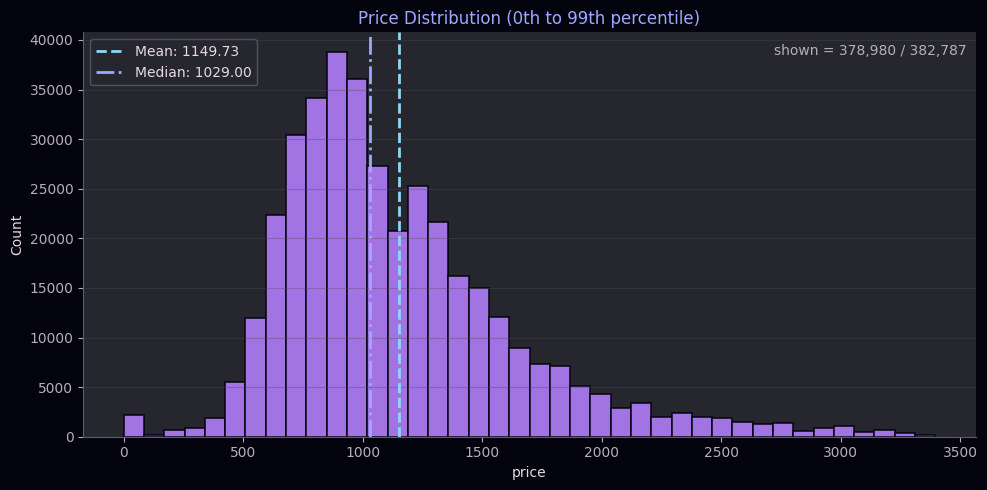

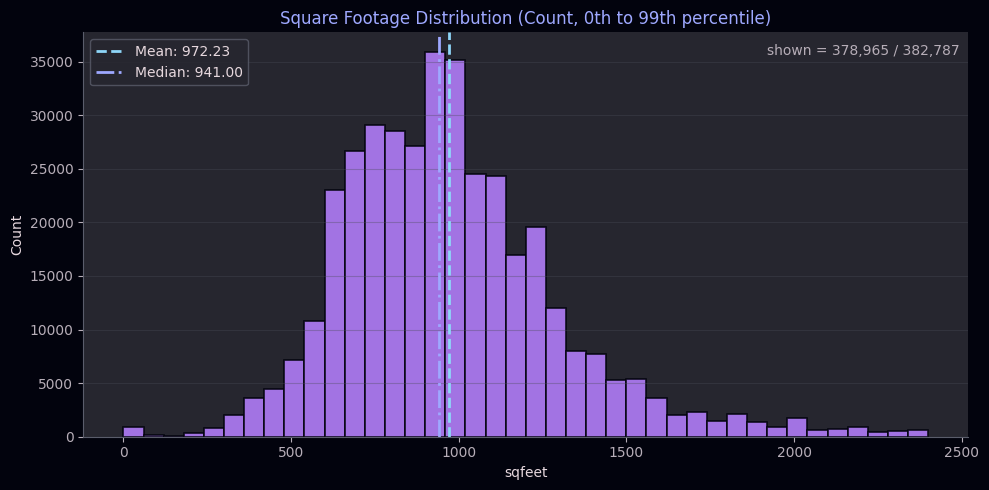

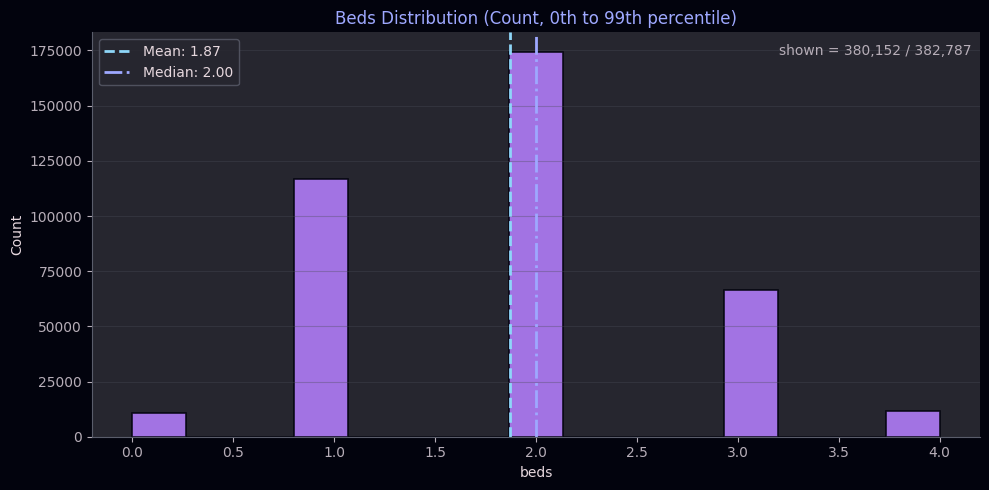

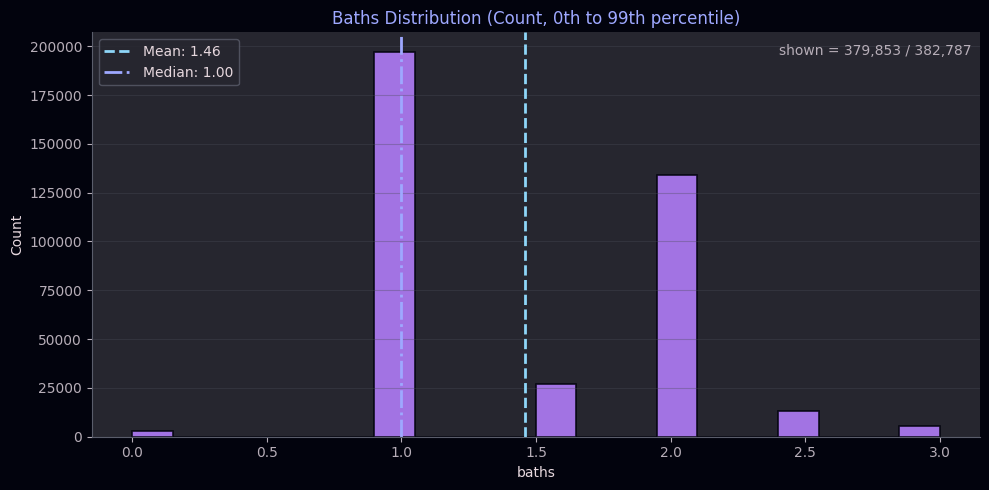

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Baths Distribution (Count, 0th to 99th percentile)'}, xlabel='baths', ylabel='Count'>)

In [368]:
def plot_hist_distribution(
    df,
    column,
    bins=30,
    stat="count",                 # "count" or "percent"
    figsize=(10, 5),
    title=None,
    x_range=None,                 # tuple like (0, 5000)
    clip_quantiles=None,          # tuple like (0.01, 0.99)
    log_x=False
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import PercentFormatter

    s = pd.to_numeric(df[column], errors="coerce").dropna()

    if s.empty:
        raise ValueError(f"No numeric values found in '{column}'.")

    original_n = len(s)

    # log transform if requested
    if log_x:
        s = s[s > 0]
        s = np.log10(s)

    # zoom to a manual range
    if x_range is not None:
        s = s[(s >= x_range[0]) & (s <= x_range[1])]

    # or zoom using quantiles
    elif clip_quantiles is not None:
        q_low, q_high = s.quantile(clip_quantiles[0]), s.quantile(clip_quantiles[1])
        s = s[(s >= q_low) & (s <= q_high)]

    if s.empty:
        raise ValueError("No data left after applying range/quantile filter.")

    fig, ax = plt.subplots(figsize=figsize)

    weights = None
    ylabel = "Count"
    if stat.lower() == "percent":
        weights = np.ones(len(s)) * 100 / len(s)
        ylabel = "Percent"

    ax.hist(
        s,
        bins=bins,
        weights=weights,
        color=theme["purple"],
        edgecolor=theme["figure_bg"],
        linewidth=1.2,
        alpha=0.9
    )

    mean_val = s.mean()
    median_val = s.median()

    ax.axvline(mean_val, color=theme["blue"], linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color=theme["lavender"], linestyle="-.", linewidth=2, label=f"Median: {median_val:.2f}")

    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(f"log10({column})" if log_x else column)
    ax.set_ylabel(ylabel)

    if stat.lower() == "percent":
        ax.yaxis.set_major_formatter(PercentFormatter())

    ax.grid(axis="y", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.99, 0.97,
        f"shown = {len(s):,} / {original_n:,}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=theme["muted"]
    )

    ax.legend()
    plt.tight_layout()
    
    #print(title.split("(", 1)[0])
    title_1=f"hist_{title.split('(', 1)[0]}"
    #print(title_1)
    plt.savefig(f"{folder}/{title_1}.png")
    plt.show()

    return fig, ax

# show main 98% of the data
plot_hist_distribution(
    df_cleaned,
    "price",
    bins=40,
    clip_quantiles=(0.000, 0.99),
    title="Price Distribution (0th to 99th percentile)"
)

# plot_hist_distribution(df_cleaned, "price", bins=40, stat="percent",
#                        clip_quantiles=(0.000, 0.99),
#                        title="Price Distribution (Percent, 0th to 99th percentile)")



# plot_hist_distribution(df_cleaned, "sqfeet", bins=40, stat="percent",
#                        clip_quantiles=(0.000, 0.99),
#                        title="Square Footage Distribution (Percent, 0th to 99th percentile)")

plot_hist_distribution(
    df_cleaned,
    "sqfeet",
    bins=40,
    stat="count",
    clip_quantiles=(0.000, 0.99),
    title="Square Footage Distribution (Count, 0th to 99th percentile)"
)

# plot_hist_distribution(df_cleaned, "beds", bins=15, stat="percent",
#                        clip_quantiles=(0.000, 0.99),
#                        title="Beds Distribution (Percent, 0th to 99th percentile)")

plot_hist_distribution(
    df_cleaned,
    "beds",
    bins=15,
    stat="count",
    clip_quantiles=(0.000, 0.99),
    title="Beds Distribution (Count, 0th to 99th percentile)"
)

# plot_hist_distribution(df_cleaned, "baths", bins=20, stat="percent",
#                        clip_quantiles=(0.000, 0.99),
#                        title="Baths Distribution (Percent, 0th to 99th percentile)")

plot_hist_distribution(
    df_cleaned,
    "baths",
    bins=20,
    stat="count",
    clip_quantiles=(0.000, 0.99),
    title="Baths Distribution (Count, 0th to 99th percentile)"
)

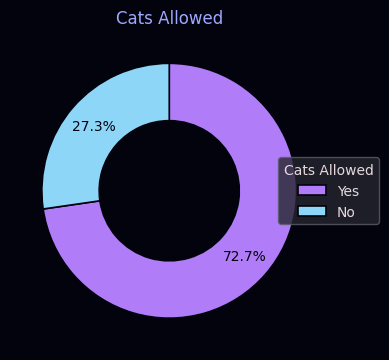

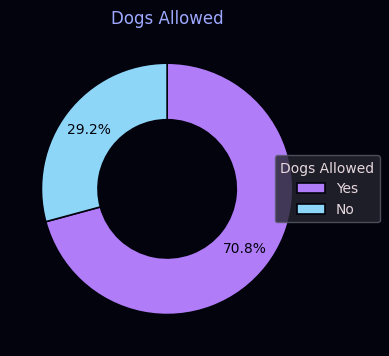

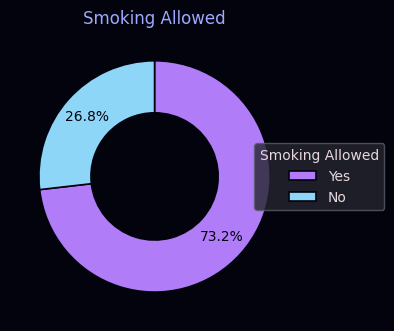

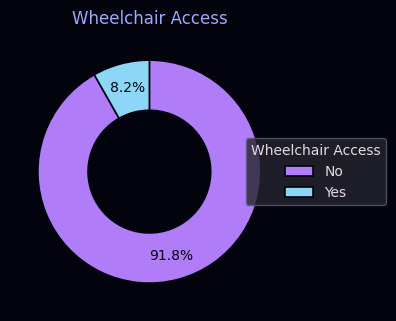

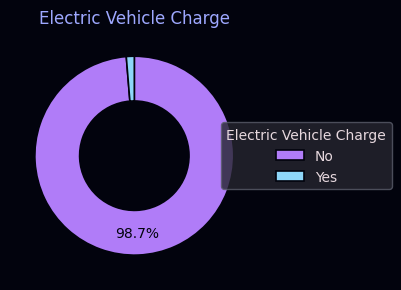

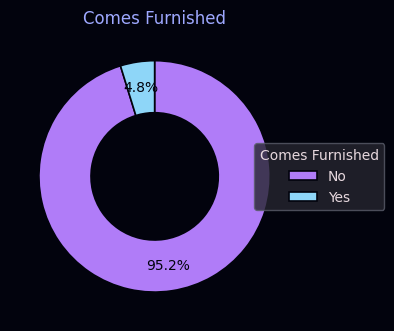

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Comes Furnished'}>)

In [369]:
# ---------- 2) pie chart ----------
def plot_pie_distribution(
    df,
    column,
    mode="regular",        # "regular" or "stacked"
    stack_by=None,         # needed when mode="stacked"
    figsize=(8, 8),
    title=None,
    donut=True,
    top_n=None,
    group_position="inner"   # "inner" or "outer"
):
    """
    Plot a pie chart distribution.

    Regular mode:
        - one categorical column

    Stacked mode:
        - nested donut chart
        - inner ring = `column`
        - outer ring = `stack_by` split inside each `column`
    """
    base_colors = [
        theme["purple"],
        theme["blue"],
        theme["lavender"],
        "#C9A7FF",
        "#A5E3FF"
    ]

    if mode not in {"regular", "stacked"}:
        raise ValueError("mode must be 'regular' or 'stacked'")

    fig, ax = plt.subplots(figsize=figsize)

    if mode == "regular":
        counts = df[column].fillna("Missing").astype(str).value_counts()

        if top_n is not None and len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = counts.iloc[top_n:].sum()
            counts = pd.concat([top, pd.Series({"Other": other})])

        colors = [base_colors[i % len(base_colors)] for i in range(len(counts))]

        wedgeprops = dict(
            edgecolor=theme["figure_bg"],
            linewidth=1.2
        )
        if donut:
            wedgeprops["width"] = 0.45

        wedges, _, _ = ax.pie(
            counts.values,
            labels=None,
            colors=colors,
            startangle=90,
            counterclock=False,
            autopct=lambda pct: _autopct_if_big(pct, threshold=3),
            pctdistance=0.78 if donut else 0.7,
            wedgeprops=wedgeprops,
            textprops={"color": theme["text_1"]}
        )

        total = counts.sum()
        counts.index = counts.index.map(lambda x: {"1": "Yes", "0": "No"}.get(x, x))
        #counts = counts.map({"1": "Yes", "0": "No"})
        #print(counts)
        legend_labels = [
            #f"{label}: {value:,} ({value/total:.1%})"
            f"{label}"
            for label, value in counts.items()
        ]

        ax.legend(
            wedges,
            legend_labels,
            title=title,
            loc="center left",
            bbox_to_anchor=(0.82, 0.5),
            frameon=True
        )

        #if donut:
        #    ax.text(
        #        0, 0,
        #        f"{column}\n{total:,}",
        #        ha="center",
        #        va="center",
        #        color=theme["text"],
        #        fontsize=12
        #    )

        ax.set_title(title or f"{column} Distribution")
        ax.set_aspect("equal")
        plt.tight_layout()
        #print(title.split("(", 1)[0])
        #title_1=title.split("(", 1)[0]
        title_1=f"pie_{title.split('(', 1)[0]}"
        plt.savefig(f"{folder}/{title_1}.png")
        plt.show()
        return fig, ax

    # ----- stacked / nested donut -----
    # ----- stacked / nested donut -----
    if stack_by is None:
        raise ValueError("stack_by is required when mode='stacked'")
    
    if group_position not in {"inner", "outer"}:
        raise ValueError("group_position must be 'inner' or 'outer'")
    
    data = df[[column, stack_by]].copy()
    data[column] = data[column].fillna("Missing").astype(str)
    data[stack_by] = data[stack_by].fillna("Missing").astype(str)
    
    ct = pd.crosstab(data[column], data[stack_by])
    
    group_labels = ct.index.tolist()
    group_sizes = ct.sum(axis=1).values
    group_colors = [base_colors[i % len(base_colors)] for i in range(len(group_labels))]
    
    detail_labels = []
    detail_sizes = []
    detail_colors = []
    
    for i, group in enumerate(ct.index):
        row = ct.loc[group]
        non_zero = row[row > 0]
    
        if len(non_zero) == 1:
            factors = [1.15]
        else:
            factors = np.linspace(0.8, 1.25, len(non_zero))
    
        for j, (detail, value) in enumerate(non_zero.items()):
            detail_labels.append(f"{detail}: {value:,}")
            detail_sizes.append(value)
            detail_colors.append(_adjust_lightness(group_colors[i], factors[j]))
    
    if group_position == "inner":
        inner_sizes = group_sizes
        inner_labels = group_labels
        inner_colors = group_colors
    
        outer_sizes = detail_sizes
        outer_labels = detail_labels
        outer_colors = detail_colors
    
        legend1_title = column
        legend2_title = f"{column} | {stack_by}"
    
    else:  # group_position == "outer"
        inner_sizes = detail_sizes
        inner_labels = detail_labels
        inner_colors = detail_colors
    
        outer_sizes = group_sizes
        outer_labels = group_labels
        outer_colors = group_colors
    
        legend1_title = stack_by
        legend2_title = column
    
    inner_wedges, _, _ = ax.pie(
        inner_sizes,
        radius=0.72,
        labels=None,
        colors=inner_colors,
        startangle=90,
        counterclock=False,
        autopct=lambda pct: _autopct_if_big(pct, threshold=5),
        pctdistance=0.72,
        wedgeprops=dict(
            width=0.26,
            edgecolor=theme["figure_bg"],
            linewidth=1.2
        ),
        textprops={"color": theme["text_1"]}
    )
    
    outer_wedges, _, _ = ax.pie(
        outer_sizes,
        radius=1.0,
        labels=None,
        colors=outer_colors,
        startangle=90,
        counterclock=False,
        autopct=lambda pct: _autopct_if_big(pct, threshold=5),
        pctdistance=0.88,
        wedgeprops=dict(
            width=0.26,
            edgecolor=theme["figure_bg"],
            linewidth=1.2
        ),
        textprops={"color": theme["text_1"]}
    )
    
    ax.text(
        0, 0,
        f"{column}\nand\n{stack_by}",
        ha="center",
        va="center",
        color=theme["text"],
        fontsize=11
    )
    
    inner_total = np.sum(inner_sizes)
    #print(inner_sizes)
    #label = label.split(":", 1)[0]
    inner_legend_labels = [
        #f"{label}: {value:,} ({value/inner_total:.1%})"
        f"{label.split(":", 1)[0]}: {value/inner_total:.1%}"
        #f"{value/inner_total:.1%}"
        for label, value in zip(inner_labels, inner_sizes)
    ]
    
    outer_total = np.sum(outer_sizes)
    outer_legend_labels = [
        #f"{label}: {value:,} ({value/outer_total:.1%})"
        f"{label}: {value/outer_total:.1%}"
        for label, value in zip(outer_labels, outer_sizes)
    ]
    
    leg1 = ax.legend(
        inner_wedges,
        inner_legend_labels,
        title=legend1_title,
        loc="upper left",
        bbox_to_anchor=(0.82, 1.0),
        frameon=True
    )
    ax.add_artist(leg1)
    
    ax.legend(
        outer_wedges,
        outer_legend_labels,
        title=legend2_title,
        loc="center left",
        bbox_to_anchor=(0.92, 0.35),
        frameon=True
    )
    
    ax.set_title(title or f"{column} by {stack_by}")
    ax.set_aspect("equal")
    plt.tight_layout()
    #print(title.split("(", 1)[0])
    #title_1=title.split("(", 1)[0]
    title_1=f"pie_{title.split('(', 1)[0]}"
    plt.savefig(f"{folder}/{title_1}.png")
    plt.show()
    
    return fig, ax



#print(df_cleaned.columns)
#plot_pie_distribution(df_cleaned, "type", figsize = (4,4), title="Type Distribution")
plot_pie_distribution(df_cleaned, "cats_allowed", figsize = (4,4), title="Cats Allowed")
plot_pie_distribution(df_cleaned, "dogs_allowed", figsize = (4,4), title="Dogs Allowed")
plot_pie_distribution(df_cleaned, "smoking_allowed", figsize = (4,4), title="Smoking Allowed")
plot_pie_distribution(df_cleaned, "wheelchair_access", figsize = (4,4), title="Wheelchair Access")
plot_pie_distribution(df_cleaned, "electric_vehicle_charge", figsize = (4,4), title="Electric Vehicle Charge")
plot_pie_distribution(df_cleaned, "comes_furnished", figsize = (4,4), title="Comes Furnished")
#plot_pie_distribution(df_cleaned, "laundry_options", figsize = (4,4), title="Laundry Options Distribution")
#plot_pie_distribution(df_cleaned, "parking_options", figsize = (4,4), title="Parking Options Distribution")


KeyError: "None of [Index(['laundry_group', 'laundry_detail'], dtype='str')] are in the [columns]"

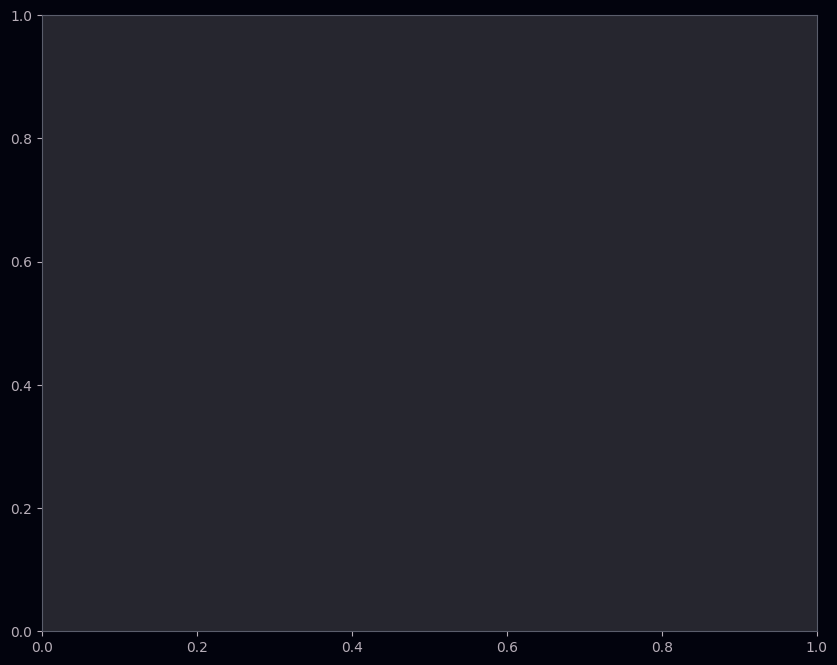

In [370]:
plot_pie_distribution(
    df_cleaned,
    column="laundry_group",
    mode="stacked",
    stack_by="laundry_detail",
    group_position="outer",
    title="Laundry Options",
    figsize=(10, 8)
)

print(df_cleaned["parking_options"].dropna().unique())

no_parking_values = [
    "no parking",
    "none"
]

parking_raw = df_cleaned["parking_options"]
parking_clean = parking_raw.fillna("").str.strip().str.lower()

is_missing = parking_raw.isna() | parking_clean.eq("")

df_cleaned["parking_group"] = np.select(
    [
        is_missing,
        parking_clean.isin(no_parking_values)
    ],
    [
        "Missing",
        "No"
    ],
    default="Yes"
)

df_cleaned["parking_detail"] = np.select(
    [
        df_cleaned["parking_group"].eq("Missing"),
        df_cleaned["parking_group"].eq("No")
    ],
    [
        "Missing",
        "No parking"
    ],
    default=df_cleaned["parking_options"]
)

plot_pie_distribution(
    df_cleaned,
    column="parking_group",
    mode="stacked",
    stack_by="parking_detail",
    group_position="outer",
    title="Parking Options",
    figsize=(10, 8)
)

In [ ]:
def find_value(df, value):
    mask = df.astype(str).eq(value)
    found = mask.any().any()
    rows = df[mask.any(axis=1)]
    locations = list(mask.stack()[lambda x: x].index)

    print(found)
    print(rows)
    print(locations)
    return found, rows, locations

find_value(X_train_final, "value")
find_value(X_test_final, "value")
find_value(X_train_final, "Missing")
find_value(X_test_final, "Missing")

False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, region, location_cluster]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, region, location_cluster]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, region, location_cluster]
Index: []
[]
False
Empty DataFrame
Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, region, locatio

(np.False_,
 Empty DataFrame
 Columns: [sqfeet, beds, baths, cats_allowed, dogs_allowed, smoking_allowed, wheelchair_access, electric_vehicle_charge, comes_furnished, lat, long, type, laundry_options, parking_options, state, region, location_cluster]
 Index: [],
 [])

In [ ]:
cutoffs = {
    "price": (1, max(df["price"])),
    "sqfeet": (70, max(df["sqfeet"]))
}

outlier_counts = check_outliers_multiple(df_cleaned, cutoffs)
print(outlier_counts)

print(f"These properties represent {(outlier_counts['total'] / start_size) * 100:.2f}% of the dataset.")


{'price': 1299, 'sqfeet': 924, 'total': 2223}
These properties represent 0.58% of the dataset.
